<div class="alert alert-block alert-info">
	<b></b> Привет, Станислав! <br>Меня зовут Кирилл Бобылев, я ревьюер на курсе DLE и буду делать ревью твоей работы. В практикуме мы общаемся на “ты”, но если для тебя это не комфортно - дай знать в комментарии. <br><br>
	
По ходу работы я буду оставлять комментарии с делением на категории: <br><font color='green'>Хорошо</font> - говорит само за себя :) <br><font color='red'>Требует доработки</font> - обязательно для исправления <br><font color='yellow'>Можно улучшить</font> - не обязательно для исправления, но стоит обратить внимание

Пожалуйста, не удаляй мои комментарии! При необходимости можешь их сдвинуть.
</div>

Кирилл Привет!

# Проект Retrieval-система по статьям с arXiv

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
!pip install pympler regex pylatexenc faiss_cpu langchain_community langchain-huggingface pypdf 

In [3]:
!pip install torch transformers datasets numpy seaborn matplotlib pandas

# Подготовка окружения (пути, seed, imports)

In [2]:
import os
import random
from pathlib import Path
import sys
from pympler import asizeof
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from torch import Tensor
import time
from functools import wraps

from tqdm import tqdm
import psutil
from transformers import (
    AutoModel,
    AutoModelForCausalLM,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    )
from pylatexenc.latex2text import LatexNodes2Text
import faiss
import pickle

from typing import List, Optional
from datasets import load_dataset, Dataset

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

/home/ubuntu/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Фиксируем seed
def fix_all_seeds(seed=42):
    """
    Функция фиксирует все возможные random seed
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print(f"Все сиды зафиксированы: {seed}")


RANDOM_SEED = 42
fix_all_seeds(RANDOM_SEED)
DATA_DIR = "nlp_s3_project"
#DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/Retrieval-nlp-yandexpracticum/nlp_s3_project"

Все сиды зафиксированы: 42


In [4]:
def print_memory_usage():
    """
    Функция выводит текущее использование оперативной памяти
    необходима для анализа потребления памяти во время выполнения кода
    """
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / (1024**3)
    mem2 = psutil.virtual_memory()
    print(f"Использование оперативной памяти от процесса: {mem:.2f} ГБ")
    print(f"Всего оперативной памяти: {mem2.total / 1024**3:.2f} ГБ")
    print(f"Фактически занято системой и процессами: {mem2.used / 1024**3:.2f} ГБ")
    print(f"Свободно: {mem2.available / 1024**3:.2f} ГБ")
    print(f"Загрузка памяти: {mem2.percent}%")

In [5]:
# Фиксируем параметры вывода для pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Фиксируем параметры визуализации графиков
sns.set_style("white")
sns.set_theme(style="whitegrid")

# Загрузка датасета

In [6]:
# Загрузка датасета
print_memory_usage()
dataset_arxiv_s = load_dataset("json", data_files=DATA_DIR +'/arxiv-metadata-s.json')
dataset_csv = load_dataset("csv", data_files=DATA_DIR +'/test_sample.csv')
print_memory_usage()

Использование оперативной памяти от процесса: 0.78 ГБ
Всего оперативной памяти: 15.61 ГБ
Фактически занято системой и процессами: 12.86 ГБ
Свободно: 2.75 ГБ
Загрузка памяти: 82.4%
Использование оперативной памяти от процесса: 0.79 ГБ
Всего оперативной памяти: 15.61 ГБ
Фактически занято системой и процессами: 12.85 ГБ
Свободно: 2.76 ГБ
Загрузка памяти: 82.3%


# EDA

In [ ]:
# Визуализируем таблицу arxiv-metadata-s.json
print(dataset_arxiv_s)
# Устанавливаем формат вывода
dataset_arxiv_s['train'].set_format("pandas")
dataset_arxiv_s['train'][:10]

DatasetDict({
    train: Dataset({
        features: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed'],
        num_rows: 98213
    })
})


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0038,Maxim A. Yurkin,"Maxim A. Yurkin, Alfons G. Hoekstra",The discrete dipole approximation: an overview and recent developments,"36 pages, 1 figure; added several corrections according to the\n published erratum except for Eq.(5) (it was correct in the original paper)","J.Quant.Spectrosc.Radiat.Transf. 106, 558-589 (2007); Erratum:\n J.Quant.Spectrosc.Radiat.Transf. 171, 82-83 (2016)",10.1016/j.jqsrt.2007.01.034 10.1016/j.jqsrt.2015.11.025,None,physics.optics physics.comp-ph,http://creativecommons.org/licenses/by-nc-nd/4.0/,"We present a review of the discrete dipole approximation (DDA), which is a\ngeneral method to simulate light scattering by arbitrarily shaped particles. We\nput the method in historical context and discuss recent developments, taking\nthe viewpoint of a general framework based on the integral equations for the\nelectric field. We review both the theory of the DDA and its numerical aspects,\nthe latter being of critical importance for any practical application of the\nmethod. Finally, the position of the DDA among other methods of light\nscattering simulation is shown and possible future developments are discussed.\n","[{'created': 'Sat, 31 Mar 2007 16:25:01 GMT', 'version': 'v1'}, {'created': 'Tue, 29 Mar 2022 17:39:15 GMT', 'version': 'v2'}]",2022-03-30,"[[Yurkin, Maxim A., ], [Hoekstra, Alfons G., ]]"
1,0704.0057,Philipp Werner,Philipp Werner and Andrew J. Millis,High-spin to low-spin and orbital polarization transitions in\n multiorbital Mott systems,Published version,"Phys. Rev. Lett. 99, 126405 (2007)",10.1103/PhysRevLett.99.126405,None,cond-mat.str-el,None,"We study the interplay of crystal field splitting and Hund coupling in a\ntwo-orbital model which captures the essential physics of systems with two\nelectrons or holes in the e_g shell. We use single site dynamical mean field\ntheory with a recently developed impurity solver which is able to access strong\ncouplings and low temperatures. The fillings of the orbitals and the location\nof phase boundaries are computed as a function of Coulomb repulsion, exchange\ncoupling and crystal field splitting. We find that the Hund coupling can drive\nthe system into a novel Mott insulating phase with vanishing orbital\nsusceptibility. Away from half-filling, the crystal field splitting can induce\nan orbital selective Mott state.\n","[{'created': 'Sun, 1 Apr 2007 19:58:35 GMT', 'version': 'v1'}, {'created': 'Wed, 19 Sep 2007 18:33:51 GMT', 'version': 'v2'}]",2009-11-13,"[[Werner, Philipp, ], [Millis, Andrew J., ]]"
2,0704.0060,Carlos Bertulani,"C.A. Bertulani, G. Cardella, M. De Napoli, G. Raciti, and E. Rapisarda",Coulomb excitation of unstable nuclei at intermediate energies,"12 pages, 2 figures, accepted for publication in Phys. Lett. B","Phys.Lett.B650:233-238,2007",10.1016/j.physletb.2007.05.029,None,nucl-th,None,"We investigate the Coulomb excitation of low-lying states of unstable nuclei\nin intermediate energy collisions ($E_{lab}\sim10-500$ MeV/nucleon). It is\nshown that the cross sections for the $E1$ and $E2$ transitions are larger at\nlower energies, much less than 10 MeV/nucleon. Retardation effects and Coulomb\ndistortion are found to be both relevant for energies as low as 10 MeV/nucleon\nand as high as 500 MeV/nucleon. Implications for studies at radioactive beam\nfacilities are discussed.\n","[{'created': 'Sat, 31 Mar 2007 22:24:53 GMT', 'version': 'v1'}, {'created': 'Mon, 21 May 2007 16:23:27 GMT', 'version': 'v2'}]",2008-11-26,"[[Bertulani, C. A., ], [Cardella, G., ], [De Napoli, M., ], [Raciti, G., ], [Rapisarda, E., ]]"
3,0704.0070,Yanzhang He,He Yanzhang and Bao Chengguang,Coincidence of the oscillations in the dipole transition and in the\n persistent current of narrow quantum rings with two electrons,"5 pages, 4 figures, submitted",J. Phys.: Condens. Matter 20 (2008) 055214,None,None,cond-mat.mes-ha

In [ ]:
# Анализируем сколько весит датасет
total_size = asizeof.asizeof(dataset_arxiv_s)

# Конвертируем в мегабайты для удобства
size_mb = total_size / (1024 * 1024)

print(f"Общий объем данных dataset_arxiv_s в RAM: {size_mb:.2f} MB")

Общий объем данных dataset_arxiv_s в RAM: 290.52 MB


In [ ]:
# Визуализируем таблицу test_sample.csv

print(dataset_csv)
dataset_csv['train'].set_format("pandas")
dataset_csv['train'][:10]

DatasetDict({
    train: Dataset({
        features: ['id', 'abstract', 'query'],
        num_rows: 1000
    })
})


,id,abstract,query
0,2412.16732,"A new platinate was recently discovered when Nd2O3 was explored as a platinum\ncapture material in the Ostwald process, formed by a direct reaction between\nPtO2(g) and Nd2O3. The crystal structure of this new platinate and its\ncomposition, Nd10.67Pt4O24 , are here reported for the first time. The compound\nis synthesized either by a direct reaction using PtO2(g) or by the citric acid\nchemical route. Based on 3-dimensional electron diffraction data and Rietveld\nrefinement of high-resolution synchrotron and neutron powder diffraction data,\nwe accurately describe its crystal structure in space group I41/a. The compound\nis structurally related to the Ln11-xSrxIr4O24 (Ln = La, Pr, Nd, Sm) phases\nwith a double-perovskite (A2BB'O6) like crystal structure and A-site\ncation-deficiency. Owing to the fixed oxidation state of Pt(IV), two of the\nfour Nd-sites are partly occupied to provide charge neutrality, with the Nd4\nsite taking a split position. On heating, Nd10.67Pt4O24 decomposes into Nd2O3\nand Pt. A plateau in the thermogravimetric curves measured in 33 vol. % O2 in\nN2 indicates the presence of an intermediate Pt(II) phase at around 960\n{\deg}C, probably isostructural with La4PtO7.\n",What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under thermal conditions?
1,nucl-th/9602019,"The production cross sections of various fragments from proton-induced\nreactions on $^{56}$Fe and $^{27}$Al have been analyzed by the Quantum\nMolecular Dynamics (QMD) plus Statistical Decay Model (SDM). It was found that\nthe mass and charge distributions calculated with and without the statistical\ndecay have very different shapes. These results also depend strongly on the\nimpact parameter, showing an importance of the dynamical treatment as realized\nby the QMD approach. The calculated results were compared with experimental\ndata in the energy region from 50 MeV to 5 GeV. The QMD+SDM calculation could\nreproduce the production cross sections of the light clusters and\nintermediate-mass to heavy fragments in a good accuracy. The production cross\nsection of $^{7}$Be was, however, underpredicted by approximately 2 orders of\nmagnitude, showing the necessity of another reaction mechanism not taken into\naccount in the present model.\n",How does the inclusion of statistical decay affect the shape of mass and charge distributions in quantum molecular dynamics simulations?
2,2501.05500,"This survey provides a comprehensive examination of verifiable computing,\ntracing its evolution from foundational complexity theory to modern\nzero-knowledge succinct non-interactive arguments of knowledge (ZK-SNARKs). We\nexplore key developments in interactive proof systems, knowledge complexity,\nand the application of low-degree polynomials in error detection and\nverification protocols. The survey delves into essential mathematical\nframeworks such as the Cook-Levin Theorem, the sum-check protocol, and the GKR\nprotocol, highlighting their roles in enhancing verification efficiency and\nsoundness. By systematically addressing the limitations of traditional NP-based\nproof systems and then introducing advanced interactive proof mechanisms to\novercome them, this work offers an accessible step-by-step introduction for\nnewcomers while providing detailed mathematical analyses for researchers.\nUltimately, we synthesize these concepts to elucidate the GKR protocol, which\nserves as a foundation for contemporary verifiable computing models. This\nsurvey not only reviews the historical and theoretical advancements in\nverifiable computing over the past three decades but also lays the groundwork\nfor understanding recent innovations in the field.\n",What are the core components of modern zero-knowledge proofs discussed in the context of verifiable computing?
3,2506.20892,"A critical challenge for operating fusion burning plasma in high confinement mode lies in mitigating da

In [ ]:

def compute_lengths(examples, tokenizer):
    """
    Функция для подсчета количества токенов в документе
    """
    # Токенизируем батч текстов
    # Мы не используем truncation=True, так как хотим узнать реальную длину
    tokenized = tokenizer(examples["abstract"].tolist(), add_special_tokens=False)

    # Возвращаем все оригинальные колонки плюс новую 'token_length'
    result = {k: v for k, v in examples.items()}
    result["token_length"] = [len(ids) for ids in tokenized["input_ids"]]
    return result
# модель для оценки ПРИМЕРНОЙ количества токенов легковесная
tokenizer_name = "clips/e5-small-trm-nl"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name, use_fast=True)

# 1. Считаем длину для каждой строки в датасете
# Используем batched=True для скорости
dataset_with_lengths = dataset_arxiv_s.map(compute_lengths, batched=True, fn_kwargs = {"tokenizer": tokenizer}, load_from_cache_file=False )

# 2. Фильтруем строки, где длина больше 512
long_sequences = dataset_with_lengths.filter(lambda x: x["token_length"] > 512)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/965 [00:00<?, ?B/s]

Map:   0%|          | 0/98213 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (523 > 512). Running this sequence through the model will result in indexing errors


Filter:   0%|          | 0/98213 [00:00<?, ? examples/s]

In [ ]:
# 3. Выводим результаты для анализа
print(f"Всего строк в датасете: {len(dataset_with_lengths['train'])}")
print(f"Строк длиннее 512 токенов: {len(long_sequences['train'])}")

if len(long_sequences['train']) > 0:
    # Посмотрим на статистику длинных строк
    lengths = long_sequences['train']["token_length"]
    print(f"Максимальная длина: {max(lengths)}")
    print(f"Средняя длина 'длинных' строк: {sum(lengths) / len(lengths):.2f}")

    # Посмотрим на первый пример такой строки
    print("\nПример длинной строки (первые 150 символов):")
    print(long_sequences['train']["abstract"][1][:150], "...")
else:
    print("Все строки уложились в лимит 512 токенов!")

Всего строк в датасете: 98213
Строк длиннее 512 токенов: 1096
Максимальная длина: 953
Средняя длина 'длинных' строк: 578.86

Пример длинной строки (первые 150 символов):
  Using spectroscopic ellipsometry, we study the optical conductivity
sigma(omega) of insulating LaSrMnO4 in the energy range of 0.75-5.8 eV from 15
t ...


In [ ]:
# Соберем в отдельную таблицу только столбец с текстом из dataset_arxiv_s
abstract_arxiv_s = dataset_arxiv_s['train']['abstract']

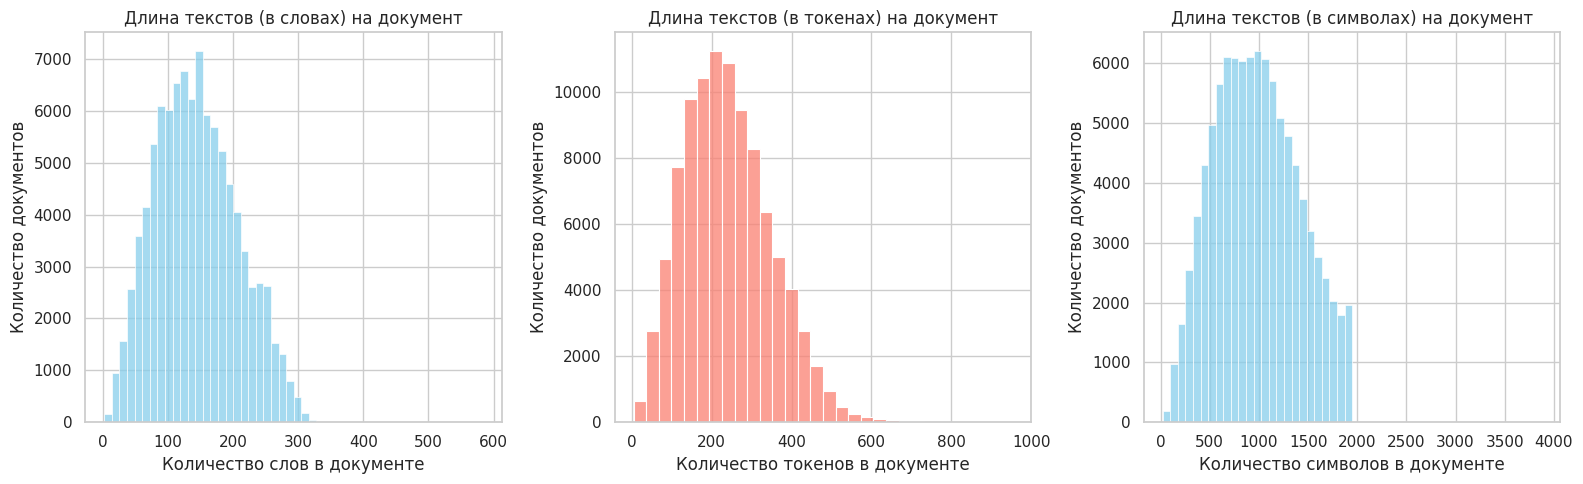

In [ ]:
# Визуализируем количество слов приходящиеся на каждый документ
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# Левый график: Длина текста
text_lens = abstract_arxiv_s.apply(lambda x: len(x.split()))
sns.histplot(x=text_lens, ax=ax[0], bins=50, color="skyblue")
ax[0].set_title("Длина текстов (в словах) на документ")
ax[0].set_xlabel("Количество слов в документе")
ax[0].set_ylabel("Количество документов")

# Средний график: Длина токенов
lenght_tok = dataset_with_lengths['train']['token_length']
sns.histplot(x=lenght_tok, ax=ax[1], bins=30, color="salmon")
ax[1].set_title("Длина текстов (в токенах) на документ")
ax[1].set_xlabel("Количество токенов в документе")
ax[1].set_ylabel("Количество документов")

# Левый график: Длина символов
chars_lens = abstract_arxiv_s.apply(lambda x: len(x))
sns.histplot(x=chars_lens, ax=ax[2], bins=50, color="skyblue")
ax[2].set_title("Длина текстов (в символах) на документ")
ax[2].set_xlabel("Количество символов в документе")
ax[2].set_ylabel("Количество документов")

plt.tight_layout()
plt.show()

In [ ]:
# Выведем распределение длины текста
text_lens.value_counts()

,count
abstract,
150,679
149,646
146,632
137,620
152,612
...,...
389,1
440,1
377,1


In [ ]:
# Выведем распределение токенов ПРЕВЫШАЮЩИХ 512 шт.
lengths.value_counts()

,count
token_length,
519,26
513,25
522,21
516,20
514,20
...,...
675,1
751,1
892,1


In [ ]:
# Проанализируем процент пропусков в колонках датасета
dataset_arxiv_s['train'].to_pandas().isna().mean()

,0
id,0.0000
submitter,0.0057
authors,0.0000
title,0.0000
comments,0.2641
journal-ref,0.6775
doi,0.5546
report-no,0.9332
categories,0.0000
license,0.1615


In [ ]:
# Проверим дубли
df = dataset_arxiv_s['train'].to_pandas()
title_duplicated = df.duplicated(subset=['title',]).sum()
abstract_duplicated = df.duplicated(subset=['abstract',]).sum()
id_duplicated = df.duplicated(subset=['id',]).sum()

print(f"Количество дубликатов по id: {id_duplicated}")
print(f"Количество дубликатов по abstract: {abstract_duplicated}")
print(f"Количество дубликатов по title: {title_duplicated}")


Количество дубликатов по id: 0
Количество дубликатов по abstract: 7
Количество дубликатов по title: 9


In [ ]:
# Посчитаем, сколько документов не содерижат латинницу, чтобы понять есть ли статьи на другиъ языках
def is_eng(text, threshold=0.8):
    import regex as re
    """
    Проверяет, содержит ли текст кириллицу больше или равно threshold
    Args:
        text (str): Текст для проверки.
        threshold (float): Пороговое значение доли кириллических символов (от 0 до 1).
    Returns:
        bool: True, если доля кириллических символов >= threshold, иначе False.
    Примеры:
        is_mostly_cyrillic("Привет, как дела?", threshold=0.8)  # True
        is_mostly_cyrillic("Hello, how are you?", threshold=0.8)    # False
    """
    # Оставляем только буквы (удаляем пробелы и знаки препинания для корректного счета)
    # Только буквы кириллицы, латиницы, китайского, японского, корейского, арабского
    letters_only = re.sub(r'[^\p{Latin}\p{Cyrillic}\p{Arabic}\p{Han}\p{Hiragana}\p{Katakana}\p{Hangul}]', '', text, flags=re.UNICODE)
    if len(letters_only) == 0:
        return False

    # Считаем количество кириллицы
    eng_chars = len(re.findall(r'[a-zA-Z]', letters_only))
    return (eng_chars / len(letters_only)) >= threshold

# Соберем предложения, которые НЕ проходят фильтр по кириллице
not_eng_docs = [s for s in abstract_arxiv_s if not is_eng(s, threshold=0.1)]
print(f"Количество предложений, которые не содержат латинницу: {len(not_eng_docs)}")

Количество предложений, которые не содержат латинницу: 0


# Выводы по EDA

1. Объем данных и память: Датасет (98к статей, 290Мб) и расчетный векторный индекс (400Мб при d=1024) полностью помещаются в RAM. Это позволяет реализовать In-memory retrieval (поиск в оперативной памяти), что критически важно для низкой задержки (latency) системы.  
2. Выбор модели: Тексты на английском языке, поэтому целесообразно использовать англоязычные эмбеддеры (например, all-MiniLM-L6-v2 или аналогичные), желательно предобученные на научном домене (Scientific domain).  
3. Длина контекста: Большинство текстов содержат 50–250 слов и укладываются в лимит 512 токенов. Наличие небольшого «хвоста» длинных текстов позволяет использовать стандартную стратегию обрезки (truncation) до 512 токенов для baseline-модели без значительной потери семантики.    
4. Препроцессинг (TeX): Тексты содержат научную нотацию в формате TeX/LaTeX. Для повышения качества токенизации требуется очистка спецсимволов ($, \) или их нормализация, чтобы формулы не превращались в «шум» для эмбеддера.  

ПЛАН ДЕЙСТВИЙ  
I. Буду строить двухэтапную систему поиска (Two-stage Retrieval).  
- Retrieval (Отбор): Быстро находим 100 наиболее похожих статей из 98k с помощью векторных представлений (эмбеддингов).  
- Reranking (Переранжирование - Cross-Encoder):  расставляем эти 100 статей в идеальном порядке для пользователя.     

II. Семантический поиск (Dense Retrieval): Будем использовать Bi-Encoder (модели типа BERT).
Индексация через FAISS (библиотека от Facebook).    
III. Модель: sentence-transformers/all-MiniLM-L6-v2 или аналогичные на базе BERT.
Ограничения:
Длина контекста: данные хорошо "влезают" в модель без обрезки.
GPU/RAM: 98к векторов займут около до 400 МБ оперативной памяти. Это позволяет держать весь индекс в памяти даже на слабом компьютере.  
IV. Препроцессинг: Объединение title и abstract в одну строку (заголовок дает важный контекст). Очистка от LaTeX-символов (в arXiv их много, типа $\).  
V. Interface: Функция/Класс, которая принимает запрос, превращает его в вектор и выдает top_k результатов.

   <div class="alert alert-block alert-success">
    <b></b> Базово согласен с архитектурой. Посмотрим реализацию
    </div>

# Предобработка датасета

In [7]:
# Очистим датасет от TeX формата

l2t = LatexNodes2Text()

# Узнаем, сколько ядер доступно на компьютере
cores = os.cpu_count()

def clean_abstract(examples):
    """
    Функция очищает текст от TeX формата
    Вход: список строк датасета с колонкой abstract
    Выход: список строк датасета с очищенной колонкой abstract
    """
    raw_texts = examples['abstract']
    try:
        # Пытаемся конвертировать TeX в текст
        examples['abstract'] = [l2t.latex_to_text(text) for text in raw_texts]
    except:
        # Если в TeX какая-то ошибка и парсер упал,
        # используем простую очистку как запасной вариант
        examples['abstract'] = [text.replace('$', '').replace('\\', '') for text in raw_texts]
    return examples

# Применяем ко всему датасету
print_memory_usage()
dataset_arxiv_s = dataset_arxiv_s.map(clean_abstract,batched=True, batch_size=1000, num_proc=cores)  # Используем все ядра процессора!
print_memory_usage()

Использование оперативной памяти от процесса: 0.79 ГБ
Всего оперативной памяти: 15.61 ГБ
Фактически занято системой и процессами: 3.83 ГБ
Свободно: 11.78 ГБ
Загрузка памяти: 24.5%
Использование оперативной памяти от процесса: 0.79 ГБ
Всего оперативной памяти: 15.61 ГБ
Фактически занято системой и процессами: 3.82 ГБ
Свободно: 11.79 ГБ
Загрузка памяти: 24.5%


In [8]:
dataset_arxiv_s['train'][2]['abstract']

'  We investigate the Coulomb excitation of low-lying states of unstable nuclei\nin intermediate energy collisions (E_lab∼10-500 MeV/nucleon). It is\nshown that the cross sections for the E1 and E2 transitions are larger at\nlower energies, much less than 10 MeV/nucleon. Retardation effects and Coulomb\ndistortion are found to be both relevant for energies as low as 10 MeV/nucleon\nand as high as 500 MeV/nucleon. Implications for studies at radioactive beam\nfacilities are discussed.\n'

In [9]:
# Удаляем дубликаты
# 1. Переводим в Pandas
df = dataset_arxiv_s['train'].to_pandas()

# 2. Удаляем дубликаты по колонке 'abstract'
# keep='first' оставит первое вхождение, остальные удалит
df = df.drop_duplicates(subset=['abstract'], keep='first', )

# 3. Возвращаем обратно в формат Hugging Face Dataset
dataset_arxiv_s['train'] = Dataset.from_pandas(df).remove_columns(['__index_level_0__'])
print(dataset_arxiv_s['train'])

Dataset({
    features: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed'],
    num_rows: 98206
})


# Функция профилирования всех компонентов системы

In [10]:
# Замерим время на каждой функции которую эта функция считает
def profile_step(func):
    @wraps(func) # Маленькая хитрость, чтобы сохранить имя функции
    def wrapper(self, *args, **kwargs):
        # --- До выполнения функции ---
        start_time = time.perf_counter()

        # --- Выполнение самой функции ---
        result = func(self, *args, **kwargs)

        # --- После выполнения функции ---
        end_time = time.perf_counter()

        # Записываем результат прямо в словарь объекта self
        duration = end_time - start_time
        self.times_stats[func.__name__] = duration

        return result
    return wrapper

# Класс RAG


In [ ]:
class RAG:

    def __init__(
        self,
        embedder_name: str = "BAAI/bge-small-en-v1.5",
        reranker_name: str = "cross-encoder/ms-marco-MiniLM-L-12-v2",
        chunk_size: int = 500,
        chunk_overlap: int = 125,
        device: Optional[str] = None,
        index_path: Optional[str] = None,
        doc_store_path: Optional[str] = None
    ):
        self.times_stats = {}
        self.device = device or ("cuda"
                                 if torch.cuda.is_available() else "cpu")
        self.emb_tokenizer = AutoTokenizer.from_pretrained(embedder_name)
        self.embedder = AutoModel.from_pretrained(embedder_name).to(
            self.device)
        self.embedder.eval()

        self.rr_tokenizer = AutoTokenizer.from_pretrained(
            reranker_name,
            padding_side='left')
        self.reranker = AutoModelForSequenceClassification.from_pretrained(
            reranker_name).to(self.device)
        self.reranker.eval()

        self.text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
        )
        self.index = None
        self.doc_store = []

        # Если пути переданы при создании — сразу загружаем
        if index_path and doc_store_path:
            self.load_index(index_path, doc_store_path)


        self.max_length = 512    

    @profile_step
    def _generate_embeddings(self, texts: List[str]) -> np.ndarray:
        inputs = self.emb_tokenizer(
            texts,
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=self.max_length,
        ).to(self.device)

        with torch.no_grad():
            outputs = self.embedder(**inputs)

        inputs.to("cpu")
        embeddings = self.last_token_pool(outputs.last_hidden_state,
                                          inputs.attention_mask).cpu()
        return F.normalize(embeddings.to(torch.float32), p=2, dim=1).numpy()

    @staticmethod
    def last_token_pool(last_hidden_states: Tensor,
                        attention_mask: Tensor) -> Tensor:
        left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
        if left_padding:
            return last_hidden_states[:, -1]
        else:
            sequence_lengths = attention_mask.sum(dim=1) - 1
            batch_size = last_hidden_states.shape[0]
            return last_hidden_states[
                torch.arange(batch_size, device=last_hidden_states.device),
                sequence_lengths]
    @profile_step
    def load_and_process_file(self, examples: dict) -> List[Document]:
        """Загрузка и экстракция данных из файлов"""

        docs = []
        for i in tqdm(range(len(examples['abstract'])),desc="loading dataset and split"):
            example = {key: values[i] for key, values in examples.items() if values is not None}
            # .pop() удаляет ключ и возвращает его значение
            abstract = example.pop('abstract')
            title = example.pop('title')
            document = Document(page_content=f"{title}\n{abstract}", metadata=example)
            docs.append(document)

        return self.text_splitter.split_documents(docs)
    @profile_step
    def build_index(self, examples: dict, batch_size: int = 32, doc_store_path: str ='doc_store.pkl', index_path: str ='docs.index') -> None:
        """Строим индекс FAISS"""
        self.doc_store = self.load_and_process_file(examples)

        # Вычислим numpy-эмбеддинги по батчам
        embeddings = []
        for i in tqdm(range(0, len(self.doc_store), batch_size), desc="Embedding chunks"):
            batch = [doc.page_content for doc in self.doc_store[i:i + batch_size]]
            embeddings.append(self._generate_embeddings(batch))

        embeddings = np.concatenate(embeddings)

        # Инициализируем индекс
        self.index = faiss.IndexFlatL2(embeddings.shape[1])
        self.index.add(embeddings)
        # Сохранить
        faiss.write_index(self.index, index_path)
        # 2. Сохраняем список чанков (doc_store) через pickle
        with open(doc_store_path, 'wb') as f:
            pickle.dump(self.doc_store, f)
        print(f"Индекс и тексты сохранены: {index_path}, {doc_store_path}")

    @profile_step
    def load_index(self, index_path: str, doc_store_path: str):
        """Загружаем всё с диска"""
        # 1. Загружаем FAISS
        self.index = faiss.read_index(index_path)
        # 2. Загружаем тексты
        with open(doc_store_path, 'rb') as f:
            self.doc_store = pickle.load(f)
        print(f"Индекс и чанки загружены! Чанков в базе: {len(self.doc_store)}")

    @staticmethod
    def get_detailed_instruct(task_description: str, query: str):
        return f'Instruct: {task_description}\nQuery:{query}'

    @staticmethod
    def format_reranker_instruction(query, doc, instruction=None):
        if instruction is None:
            instruction = 'Given a web search query, retrieve relevant passages that answer the query'
        output = "<Instruct>: {instruction}\n<Query>: {query}\n<Document>: {doc}".format(
            instruction=instruction, query=query, doc=doc)
        return output

    @profile_step
    def process_inputs(self, pairs):
        """
        Функция для подготовки входов для модели реранкера. Она принимает пары [Запрос, Документ]
        и возвращает токенизированные тензоры, готовые для подачи в модель.
        """
        inputs = self.rr_tokenizer(
            pairs, # Для Cross-Encoder пары подаются как список кортежей: [('запрос', 'текст1'), ...]
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=self.max_length
        )
        
        # Для моделей типа BERT/MiniLM часто нужно удалять token_type_ids,
        # если они вызывают ошибку размера тензора
        if "token_type_ids" in inputs:
            del inputs["token_type_ids"]

        for key in inputs:
            inputs[key] = inputs[key].to(self.device)
        return inputs


    @profile_step
    def search(
        self,
        query: str,
        k: int = 5,
        task: str = None):
        if self.index is None:
            raise ValueError("Index not initialized")

        if task is None:
            task = 'Given a web search query, retrieve relevant passages that answer the query'

        query_embedding = self._generate_embeddings([query])
        distances, indices = self.index.search(query_embedding, k)
        return distances, indices

    @torch.no_grad()
    def compute_logits(self, inputs):
        """получаем число-оценку релевантности"""
        logits = self.reranker(**inputs).logits
        # MiniLM выдает один лоджит на пару. Мы его выпрямляем в список.
        batch_scores = logits.view(-1).float().cpu().tolist()
        return batch_scores

    @profile_step
    def rerank(self, query: str, documents: List[str], batch_size: int = 64):
        """
        Основной метод реранкинга.
        """
        # Готовим пары [Запрос, Документ]
        pairs = [[query, doc] for doc in documents]

        scores = []
        for i in tqdm(range(0, len(pairs), batch_size), desc = 'reranking'):
            batch_pairs = pairs[i : i + batch_size]
            inputs = self.process_inputs(batch_pairs)
            batch_scores = self.compute_logits(inputs)
            scores.extend(batch_scores)
        
        return scores

   <div class="alert alert-block alert-warning">
    <b></b> В целом по коду нет вопросов, но видно, что приходится комментировать ячейки для инфера разных моделей  
    </div>

<div class="alert alert-info">
    <h2> Комментарий студента</h2>


    Да, спасибо! Убрал лишнее, действительно надо было в отдельных тетрадках делать. 
</div>   

# LLM модель ответа

In [24]:
# Подготовим функцию выдачи ответа от LLM модели
@torch.no_grad
def inference(prompt, llm_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B", ):
    """
    Функция для получения ответа от LLM
    Вход: prompt - текст запроса
    Выход: текст ответа
    """
    tokenizer = AutoTokenizer.from_pretrained(llm_name)
    model = AutoModelForCausalLM.from_pretrained(llm_name).to("cuda")
    messages = [
        {"role": "user", "content": prompt}
    ]
    start = time.time()
    print('Токенизация')
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    inputs = tokenizer([text], return_tensors="pt").to(model.device)
    print('Генерация модели {llm_name}')
    generated_ids = model.generate(**inputs, max_new_tokens=1000)

    output_ids = generated_ids[0][len(inputs.input_ids[0]):].tolist()
    print('Декодировка')
    content = tokenizer.decode(output_ids, skip_special_tokens=True).strip("\n")
    end = time.time()
    dur = end - start
    return content, dur

# Функция подсчета метрики

In [43]:
# Посчитаем функцию вычисления целевой метрики
def compute_metrics (queries: dict, rag, k = 5, N=5):
    """
    Функция оценками целевой метрики MRR (Mean Reciprocal Rank)
    Формула расчета:
       сумма(1 / (позиция первого успешного совпадения)) / количество запросов
    Вход:
    >>> Батч из датасета запросов query_dataset['train']
    Вывод: значение MRR
    """
    time_score = []
    reciprocal_rank = []
    for i in tqdm(range(len(queries['id'])), desc='compute metrics'):
        start = time.time()
        q_text = queries['abstract'][i]
        q_id = queries['id'][i]
        # 1. Поиск (Bi-Encoder)
        D, I = rag.search(q_text, k=N)

        # 2. Ранжирование (Cross-Encoder)
        # Нам нужны не только тексты, но и ID документов, чтобы проверить правильность
        candidate_indices = I[0] # Индексы в базе знаний
        candidates = [rag.doc_store[idx].page_content for idx in candidate_indices]

        # Получаем скоры и сортируем
        scores = np.array(rag.rerank(q_text, candidates))
        sorted_indices = np.argsort(scores)[::-1][:k]


        found = False
        for j, iindex in enumerate(sorted_indices):
            # Достаем реальный индекс документа из базы
            doc_idx = candidate_indices[iindex]
            # Сравниваем ID документа в базе с ID из запроса (q)
            if str(q_id) == str(rag.doc_store[doc_idx].metadata.get('id')):
                reciprocal_rank.append(1 / (j + 1))
                found = True
                break # Нашли первый правильный, дальше не ищем

        if not found:
            reciprocal_rank.append(0.0)
        end = time.time()
        dur = end - start
        time_score.append(dur)
    MRR = np.mean(reciprocal_rank)
    return MRR, time_score



# Инференс

In [32]:
def get_answer(rag: RAG, q: str, k_retrieval: int = 100, k_final: int = 5):
    """
    Функция для получения ответа на конкретный вопрос по уже готовому индексу.
    """
    start = time.time()
    # Шаг 1: Retrieval (Поиск кандидатов)
    print('Поиск')
    D, I = rag.search(q, k=k_retrieval)

    # Шаг 2: Извлечение текстов из DocStore
    candidates = [rag.doc_store[i].page_content for i in I[0]]
    print('Ранжирование')
    # Шаг 3: Reranking (Переранжирование)
    scores = rag.rerank(q, candidates)

    # Шаг 4: Выбор лучших k_final индексов
    array = np.array(scores)
    # argsort дает индексы от меньшего к большему, [::-1] переворачивает их
    top_indices = np.argsort(array)[::-1][:k_final]

    # Шаг 5: Освобождение ресурсов GPU
    # Мы выносим это в отдельный блок, чтобы не грузить память
    _cleanup_gpu(rag)

    # Шаг 6: Подготовка промпта
    prompt = f"Given texts info below give me a very short answer to a question: {q}\n\n"
    for i, idx in enumerate(top_indices):
        prompt += f"chunk {i}: {candidates[idx]}\n\n"

    # Шаг 7: Inference (Генерация ответа)
    raw_answer, dur_inference = inference(prompt=prompt)

    # Чистим ответ от технических тегов (если они есть)
    clean_answer = raw_answer.split('</think>')[-1].strip()
    end = time.time()
    dur_get_answer = end - start
    all_duration = {'Весь процесс получения ответа:': dur_get_answer, 'Только генерация ответа': dur_inference}
    return clean_answer, rag.times_stats, all_duration

def _cleanup_gpu(rag: RAG):
    """Вспомогательная функция для менеджмента памяти."""
    torch.cuda.empty_cache()
    if hasattr(rag, 'embedder'):
        rag.embedder.to("cpu")
    if hasattr(rag, 'reranker'):
        rag.reranker.to("cpu")

In [31]:
print_memory_usage()

rag = RAG()
#rag.build_index(dataset_arxiv_s['train'][:])

# 2. ВОСКРЕШАЕМ систему из сохраненных файлов
rag.load_index("docs.index", "doc_store.pkl")

# 2. Выполнение поиска и генерации
answer, stats, dur = get_answer(rag, dataset_csv['train'][0]['query'])

print_memory_usage()

Использование оперативной памяти от процесса: 5.52 ГБ
Всего оперативной памяти: 15.61 ГБ
Фактически занято системой и процессами: 11.24 ГБ
Свободно: 4.37 ГБ
Загрузка памяти: 72.0%


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4080.40it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4313.16it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-12-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Индекс и чанки загружены! Чанков в базе: 289689
Поиск
Ранжирование


Loading weights: 100%|██████████| 339/339 [00:00<00:00, 4104.92it/s]
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Токенизация
Генерация модели {llm_name}
Декодировка
Использование оперативной памяти от процесса: 5.47 ГБ
Всего оперативной памяти: 15.61 ГБ
Фактически занято системой и процессами: 10.91 ГБ
Свободно: 4.70 ГБ
Загрузка памяти: 69.9%


   <div class="alert alert-block alert-warning">
    <b></b> По остальному коду выше всё верно реализовано. Однако не совсем ясно с каким кодом было выполнено построение индекса, тут возможны ошибки, конечно, которые будет сложно отловить 
    </div>

<div class="alert alert-info">
    <h2> Комментарий студента</h2>


    Исправил
</div>
    
 

In [33]:
answer

'The newly discovered Platinate Nd10.67Pt4O24 exhibits unique decomposition behavior under thermal conditions. Upon heating, it decomposes into Nd2O3 and Pt, forming a plateau in the thermogravimetric curve at 960°C, indicating an intermediate Pt(II) phase, likely isostructural with La4PtO7. This behavior is marked by a phase transition, first from a high-temperature phase to a more stable intermediate phase upon heating.'

# Производительность

In [40]:
print('Временные параметры прохода RAG системы при получении 1 запроса и холодного старта (незагруженного индекса и базы чанков)')
stats

Временные параметры прохода RAG системы при получении 1 запроса и холодного старта (незагруженного индекса и базы чанков)


{'load_index': 16.746883832001913,
 '_generate_embeddings': 0.007728882002993487,
 'search': 0.04393475200049579,
 'process_inputs': 0.018804560000717174,
 'rerank': 0.3944574009983626}

In [39]:
print(f'Время на функцию генерации ответа с моделью с генеративной моделью')
print(dur)

Время на функцию генерации ответа с моделью с генеративной моделью
{'Весь процесс получения ответа:': 25.731877088546753, 'Только генерация ответа': 21.584603309631348}


In [ ]:
rag = RAG(
    index_path="docs.index", 
    doc_store_path="doc_store.pkl",
    reranker_name = 'cross-encoder/ms-marco-MiniLM-L-12-v2'
)
MRR, dur_mrr = compute_metrics (queries=dataset_csv['train'][:], rag=rag, N=5)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4535.91it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4176.91it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-12-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Индекс и чанки загружены! Чанков в базе: 289689


compute metrics: 100%|██████████| 1000/1000 [01:21<00:00, 12.26it/s]


In [ ]:
# Сравним разницу в метрике при ранжировании 100 кандидатов
rag2 = RAG(
    index_path="docs.index", 
    doc_store_path="doc_store.pkl",
    reranker_name = 'cross-encoder/ms-marco-MiniLM-L-12-v2'
)
MRR2, dur_mrr2 = compute_metrics (queries=dataset_csv['train'][:], rag=rag2, N=100)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3970.37it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3926.26it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-12-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Индекс и чанки загружены! Чанков в базе: 289689


compute metrics: 100%|██████████| 1000/1000 [12:51<00:00,  1.30it/s]


# Метрика MRR@5

In [45]:
print(f'Метрика MRR@5 для 5 кандидатов на входе: {MRR}')
print(f'Время на обработку одного запроса {dur_mrr}')
print(f'Метрика MRR@5 для 100 кандидатов на входе: {MRR2}')
print(f'Время на обработку одного запроса {dur_mrr2}')

Метрика MRR@5 для 5 кандидатов на входе: 0.9343166666666667
Время на обработку одного запроса [0.3787050247192383, 0.1045839786529541, 0.10687017440795898, 0.0901031494140625, 0.09779191017150879, 0.0788886547088623, 0.09335660934448242, 0.10561680793762207, 0.09165596961975098, 0.07632994651794434, 0.0977020263671875, 0.0983426570892334, 0.08022212982177734, 0.07497072219848633, 0.0922691822052002, 0.08324837684631348, 0.07405996322631836, 0.07926678657531738, 0.1044609546661377, 0.08015727996826172, 0.09295892715454102, 0.06909561157226562, 0.07834148406982422, 0.0795900821685791, 0.07644414901733398, 0.08650946617126465, 0.09378695487976074, 0.07868647575378418, 0.07835149765014648, 0.06892085075378418, 0.06159019470214844, 0.07740139961242676, 0.07867670059204102, 0.07223343849182129, 0.09488201141357422, 0.07502222061157227, 0.10004568099975586, 0.09235978126525879, 0.07097077369689941, 0.1258869171142578, 0.07166504859924316, 0.09159731864929199, 0.09579014778137207, 0.0908432006

   <div class="alert alert-block alert-info">
    <b></b> Да, а вот и подтверждение слов выше. "Из коробки" только на выбранном эмбеддере (без ранжирования) результат должен был достигать 0.8+ для не "small" версии BAAI/bge-small-en-v1.5 точно... Сейчас сложно отследить тут ошибку, т.к. ячейки не выполнены последовательно(
    </div>

<div class="alert alert-info">
    <h2> Комментарий студента</h2>


    Большое спасибо за подсказку! Я бы не догадался! Я пробовал на моделях Qwen запускать, но виртуальные машины не выдерживают и collab тоже. Все время срывалось соединение. Потому что процесс был очень медленный, часы у меня шли
    Но вот что любопытно и чего я бы сам не сообразил точно, что при добавлении количества кондидатов метрика падает. Т.е. чем больше модель ранжирования получала кандидатов на входе тем хуже были ее предсказания. Когда ты дал мне подсказку что из коробки дает такой высокий результат, это оказалось для меня большим уроком. Т.е. надо было изначально замерить только с одной моделью метрику, и уже потом наращивать
</div>
    
    
   

# Выводы:
1. Анализ производительности:
rerank (0.39 сек для 5 кандидатов на входе и batch_size = 64) - Все еще узкое горлышко в системе. Но при увеличении количества кандидатов растет очень сильно время на ранжирование
2. Анализ качества Метрика MRR@5
MRR@5 = 0.93 при количестве кандидатов при ранжировании 5 и MRR@5 = 0,51 при количестве кандидатов 100. 
0,93 это уже хороший результат значит модель почти всегда выдает отличный результат. Чтобы улучшить думаю надо еще сделать шаг по количеству кандидатов на входе, может увеличить на 1-2 может уменьшить. Ну можно модель искать с большим количеством параметров. 

   <div class="alert alert-block alert-info">
    <b></b> Опять же соглашусь, но есть нюанс, что производительность не ставилась как критерий приемки работы - только поисковая метрика качества. Резюмируя, по коду вопросов нет, однако целевой метрики сильно не хватает, к сожалению. Предлагаю поэкспериментировать с вариациями моделей типа bge-m3 без ранжирования, либо же загрузить прошлый эксперимент с qwen3 (все экспенрименты рекомедую всегда делать в разных ноутбуках/файлах)
    
Уверен, что правки не займут много времени, поскольку весь код уже готов. Жду новую итерацию!    
    </div>